# Predicting the Popularity of Online News

**Author:** Habib Kazemi  
**Course:** Big Data Analytics and Text Mining + 3CFU Project Work  
**Professor:** Dr. Stefano Lodi  
**Academic Year:** 2024-2025

---

## Classification Algorithms Implemented

This notebook implements **3 out of 6** classification algorithms using PySpark MLlib:

1. **Random Forest Classifier**
2. **Gradient-Boosted Tree Classifier**
3. **Support Vector Machine (SVM) Classifier**

> **Note:** The other 3 algorithms (Logistic Regression, Naive Bayes, Decision Tree) are implemented in the companion notebook: `big_data_3cfu.ipynb`

## Methodology

This notebook uses **PySpark MLlib** to predict online news article popularity using a **binary classification approach** with **rolling window time-series validation**, following the methodology from the reference paper.

# Data Sources and References

## Dataset
**Online News Popularity Data Set** - [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+News+Popularity)

##  Main Reference Paper

**Fernandes, K., Vinagre, P., & Cortez, P. (2015).** *A Proactive Intelligent Decision Support System for Predicting the Popularity of Online News.* In Portuguese Conference on Artificial Intelligence (EPIA 2015). Springer.

🔗 **Available at:** [Semantic Scholar](https://api.semanticscholar.org/CorpusID:7477506)


# Introduction

## Methodology Overview

This project follows the **rolling window time-series validation** approach as described in the reference paper to ensure robust model evaluation while respecting temporal dependencies in the data.

## Machine Learning Pipeline

I implemented **6 different classification algorithms** using **PySpark MLlib**, distributed across two notebooks:

### **Current Notebook (6CFU):**
4. **Random Forest Classifier**
5. **Gradient-Boosted Tree Classifier**
6. **Support Vector Machine (SVM) Classifier**

### **Companion Notebook (3CFU):**
1. **Logistic Regression**
2. **Naive Bayes**
3. **Decision Tree Classifier**


## Evaluation Metrics

All models are evaluated using comprehensive performance metrics:
- **ROC Curves** and **AUC (Area Under Curve)**
- **Accuracy**
- **F1-Score**
- **Precision** 
- **Recall**

This multi-metric approach provides a holistic view of model performance for binary classification of news article popularity.

## Python Environment and Library Requirements

### **Python Version Used**
- **Python**: 3.13

### **Required Libraries and Minimum Versions:**

| Library | Version |
|---------|---------|
| **matplotlib** | ≥3.10.8 |
| **numpy** | ≥2.4.1 |
| **pandas** | ≥3.0.0  |
| **pyspark** | ≥4.1.1 |
| **scikit-learn** | ≥1.8.0 | 


In [1]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col, row_number
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier, LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("NewsPopularityClassification_6CFU") \
    .config("spark.driver.memory", "4g") \
    .config("spark.rpc.message.maxSize", str(2047)) \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"Spark Version: {spark.version}")
print("Spark Session initialized successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/31 20:14:44 WARN Utils: Your hostname, Habibs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.205.192.217 instead (on interface en0)
26/01/31 20:14:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/31 20:14:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1
Spark Session initialized successfully!


## 1. Data Loading and Exploration

In [2]:
# Load the dataset
data = spark.read.csv("OnlineNewsPopularity.csv", header=True, inferSchema=True)

# Clean column names (remove leading/trailing spaces)
for col_name in data.columns:
    new_col = col_name.strip()
    if new_col != col_name:
        data = data.withColumnRenamed(col_name, new_col)

print(f"Total number of articles: {data.count()}")
print(f"Number of features: {len(data.columns)}")
print("\nSchema:")
data.printSchema()

Total number of articles: 39644
Number of features: 61

Schema:
root
 |-- url: string (nullable = true)
 |-- timedelta: double (nullable = true)
 |-- n_tokens_title: double (nullable = true)
 |-- n_tokens_content: double (nullable = true)
 |-- n_unique_tokens: double (nullable = true)
 |-- n_non_stop_words: double (nullable = true)
 |-- n_non_stop_unique_tokens: double (nullable = true)
 |-- num_hrefs: double (nullable = true)
 |-- num_self_hrefs: double (nullable = true)
 |-- num_imgs: double (nullable = true)
 |-- num_videos: double (nullable = true)
 |-- average_token_length: double (nullable = true)
 |-- num_keywords: double (nullable = true)
 |-- data_channel_is_lifestyle: double (nullable = true)
 |-- data_channel_is_entertainment: double (nullable = true)
 |-- data_channel_is_bus: double (nullable = true)
 |-- data_channel_is_socmed: double (nullable = true)
 |-- data_channel_is_tech: double (nullable = true)
 |-- data_channel_is_world: double (nullable = true)
 |-- kw_min_min: 

In [3]:
# Display basic statistics
print("Sample data:")
data.show(5)

print("\nShares distribution:")
data.select("shares").describe().show()

Sample data:
+--------------------+---------+--------------+----------------+---------------+----------------+------------------------+---------+--------------+--------+----------+--------------------+------------+-------------------------+-----------------------------+-------------------+----------------------+--------------------+---------------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-------------------------+-------------------------+--------------------------+-----------------+------------------+--------------------+-------------------+-----------------+-------------------+-----------------+----------+---------------+---------------+---------------+---------------+---------------+-------------------+-------------------------+--------------------------+--------------------------+-------------------+-------------------+---------------------+---------------------+---------------------+---------------------+-------------

+-------+------------------+
|summary|            shares|
+-------+------------------+
|  count|             39644|
|   mean|3395.3801836343455|
| stddev|11626.950748651709|
|    min|               1.0|
|    max|          843300.0|
+-------+------------------+



## 2. Data Preprocessing

### 2.1 Binary Label Creation
Using threshold of 1,400 shares as per the original paper.

In [4]:
# Create binary label: 1 if shares > 1400, 0 otherwise
data = data.withColumn("label", when(col("shares") > 1400, 1).otherwise(0))

# Check class distribution
print("Class distribution:")
data.groupBy("label").count().show()

# Calculate class percentages
total = data.count()
popular = data.filter(col("label") == 1).count()
unpopular = data.filter(col("label") == 0).count()
print(f"Popular (>1400 shares): {popular} ({popular/total*100:.2f}%)")
print(f"Unpopular (<=1400 shares): {unpopular} ({unpopular/total*100:.2f}%)")

Class distribution:


+-----+-----+
|label|count|
+-----+-----+
|    1|19562|
|    0|20082|
+-----+-----+

Popular (>1400 shares): 19562 (49.34%)
Unpopular (<=1400 shares): 20082 (50.66%)


### 2.2 Feature Selection

In [5]:
# Define feature columns (exclude url, timedelta, shares, and label)
# timedelta is kept for sorting but excluded from features
exclude_cols = ["url", "timedelta", "shares", "label"]
feature_cols = [col for col in data.columns if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}...")  # Show first 10

Number of feature columns: 58
Feature columns: ['n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length']...


### 2.3 Feature Vectorization

> ⚠️ **Important Note on Scaling**: Features are vectorized here but **NOT scaled yet**. 
> 
> **Scaling will be applied separately within each rolling window** to prevent data leakage by ensuring the scaler is fitted only on training data.

In [6]:
# Assemble features into a single vector (but don't scale yet!)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_data = assembler.transform(data)

# Select only necessary columns (features are unscaled at this point)
# Scaling will be done separately for each rolling window to prevent data leakage
prepared_data = assembled_data.select("timedelta", "features", "label")

print("Feature assembly complete!")
print(f"Prepared data count: {prepared_data.count()}")
print("Note: Scaling will be applied separately within each rolling window to prevent data leakage")
prepared_data.show(5)

Feature assembly complete!
Prepared data count: 39644
Note: Scaling will be applied separately within each rolling window to prevent data leakage
+---------+--------------------+-----+
|timedelta|            features|label|
+---------+--------------------+-----+
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    1|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
|    731.0|(58,[0,1,2,3,4,5,...|    0|
+---------+--------------------+-----+
only showing top 5 rows


## 3. Rolling Window Time-Series Split

Following the methodology from the reference paper to ensure temporal validity:

| Parameter | Value | Description |
|-----------|-------|-------------|
| **Window size (W)** | 10,000 samples | Size of each training/testing window |
| **Step size (L)** | 1,000 samples | Number of samples to advance between windows |
| **Train/Validation split** | 70/30 | Ratio within each window |

This approach ensures that:
- ✅ **No future data leaks into past predictions**
- ✅ **Models are evaluated on truly unseen temporal data**
- ✅ **Consistent evaluation across different time periods**

In [7]:
# Sort data by timedelta in DESCENDING order (chronological: oldest → newest)
# timedelta = days between publication and acquisition
# Large timedelta = old articles (published long ago)
# Small timedelta = new articles (published recently)
# We want: old → new (past → future) for time-series prediction
sorted_data = prepared_data.orderBy(col("timedelta").desc())

# Cache the sorted data for efficiency
sorted_data.cache()

# Improved windowing parameters
W = 10000  # Base window size for train/evaluation split
L = 1000   # Step size AND test data size
total_window_size = W + L  # Total window size = 11,000
total_rows = sorted_data.count()

print(f"Total samples: {total_rows}")
print(f"Base window (W): {W} samples → split into 70% train + 30% evaluation")
print(f"Test size (L): {L} samples → future data for testing")
print(f"Total window size: {total_window_size} samples (W + L)")
print(f"Step size: {L} samples (advance between windows)")

# Calculate number of windows
num_windows = (total_rows - total_window_size) // L + 1
print(f"Number of rolling windows: {num_windows}")

Total samples: 39644
Base window (W): 10000 samples → split into 70% train + 30% evaluation
Test size (L): 1000 samples → future data for testing
Total window size: 11000 samples (W + L)
Step size: 1000 samples (advance between windows)
Number of rolling windows: 29


In [8]:
# Add sequential row numbers for window extraction
# Using Window.row_number() - ensures proper ordering by timedelta

# Note: Window is used here to add sequential indices, not for windowed aggregations
# Using desc() order to maintain chronological order (oldest first)
window_spec = Window.orderBy(col("timedelta").desc())
data_with_row = sorted_data.withColumn("row_num", row_number().over(window_spec))
data_with_row.cache()  # Cache only the base data with row numbers

# Force materialization of data_with_row
data_with_row.count()

sorted_data.unpersist()  # Unpersist original sorted data to save memory

# Calculate number of windows with new approach
total_window_size = W + L
num_windows_to_create = (total_rows - total_window_size) // L + 1
print(f"Will process {num_windows_to_create} windows sequentially with improved approach")
print(f"Each window: W+L={total_window_size} samples → Train+Eval+Test")
print("Benefits: Perfect temporal order, true future testing, memory efficient")

Will process 29 windows sequentially with improved approach
Each window: W+L=11000 samples → Train+Eval+Test
Benefits: Perfect temporal order, true future testing, memory efficient


## 4.  Helper Functions for Training and Evaluation

This section defines comprehensive utility functions to streamline the machine learning pipeline:

### **Evaluation Function**
- Calculates multiple performance metrics (AUC, Accuracy, F1-Score, Precision, Recall)
- Provides standardized model assessment across all algorithms

### **Training Function with Grid Search**
- Implements GridSearch within each rolling window
- Performs hyperparameter optimization via grid search
- Ensures consistent training methodology across all models

In [9]:
def create_window_on_demand(data_with_row, start, W, L, total_rows):
    """
    Create a single window on-demand and scaling.
    
    Window Structure:
    1. Extract W + L samples from the dataset
    2. First W samples → Train data (TVS splits this into train/validation internally)
    3. Last L samples → Test data (future)
    4. Fit scaler on train data (W samples) ONLY
    5. Apply scaler to both train + test data
    
    Args:
        data_with_row: Base DataFrame with row numbers
        start: Starting position for THIS window
        W: Base window size for train data
        L: Test data size (and step size)
        total_rows: Total number of rows
    
    Returns:
        Tuple: (train_scaled, test_scaled)
    """
    total_window_size = W + L
    end = start + total_window_size  # Window spans W + L samples
    
    # STEP 1: Extract W + L samples for THIS window
    window_data = data_with_row.filter((col("row_num") > start) & (col("row_num") <= end))
    
    # STEP 2: Split window into two parts
    train_end = start + W  # End of train data
    
    # First W samples as train data (TVS will split this internally)
    train_raw = window_data.filter((col("row_num") > start) & (col("row_num") <= train_end)).select("features", "label")
    
    # Last L samples as test data (future samples)
    test_raw = window_data.filter((col("row_num") > train_end) & (col("row_num") <= end)).select("features", "label")
    
    # STEP 3: CRITICAL - Fit scaler on train data ONLY (prevents data leakage)
    scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
    scaler_model = scaler.fit(train_raw)  # Fit only on training data (W samples)
    
    # STEP 4: Apply the SAME scaler to both train + test data
    train_scaled = scaler_model.transform(train_raw).select(col("scaled_features").alias("features"), "label")
    test_scaled = scaler_model.transform(test_raw).select(col("scaled_features").alias("features"), "label")
    
    return train_scaled, test_scaled

In [10]:
def evaluate_model(predictions):
    """
    Evaluate model predictions using multiple metrics
    
    Args:
        predictions: DataFrame with predictions
    
    Returns:
        Dictionary with evaluation metrics
    """
    # Binary classification evaluator for AUC
    binary_evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
    auc_score = binary_evaluator.evaluate(predictions)
    
    # Multiclass evaluator for other metrics
    mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    
    accuracy = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "accuracy"})
    f1 = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "f1"})
    precision = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedPrecision"})
    recall = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedRecall"})
    
    return {
        "AUC": auc_score,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Precision": precision,
        "Recall": recall
    }

In [11]:
def train_single_algorithm_on_window(model, param_grid, train, test, model_name):
    """
    Train a single algorithm on a single window with grid search.
    
    Args:
        model: PySpark ML model (estimator)
        param_grid: ParamGrid with hyperparameters to search
        train: Scaled training data for this window
        test: Scaled test data for this window  
        model_name: Name of the model for display
    
    Returns:
        Tuple: (metrics_dict, predictions_df, best_params_dict)
    """
    # Create TrainValidationSplit for hyperparameter tuning
    tvs = TrainValidationSplit(
        estimator=model,
        estimatorParamMaps=param_grid,
        evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
        trainRatio=0.7,  # TVS splits train data into 70% train + 30% validation
        seed=42,
        parallelism=8
    )
    
    # STEP 1: Grid search on scaled train data (TVS handles internal 70/30 split)
    tvs_model = tvs.fit(train)
    
    # STEP 2: Extract best hyperparameters 
    best_model_from_validation = tvs_model.bestModel
    best_params = best_model_from_validation.extractParamMap()
    
    # Store best params for analysis
    best_params_dict = {param.name: value for param, value in best_params.items()}
    
    # STEP 3: Train final model on FULL scaled train data with best params
    final_model = model.copy(best_params)
    final_model = final_model.fit(train)
    
    # STEP 4: Evaluate on scaled test data (future samples)
    predictions = final_model.transform(test)
    
    # STEP 5: Calculate metrics and collect results
    metrics = evaluate_model(predictions)
    
    # Store predictions for ROC curve (collect to driver immediately)
    if "probability" in predictions.columns:
        pred_df = predictions.select("label", "probability").toPandas()
    else:
        # Fallback for models that don't output probability (like LinearSVC)
        # We select rawPrediction which contains the margin/score
        pred_df = predictions.select("label", "rawPrediction").toPandas()
    
    return metrics, pred_df, best_params_dict

def train_all_algorithms_efficiently(models_and_grids, data_with_row, total_rows, W, L):
    """
    Train all algorithms by traversing windows once.
    
    Instead of:
    - Train RF on all windows
    - Train GBT on all windows  
    - Train SVM on all windows
    
    We do:
    - For each window: Train RF + GBT + SVM, then move to next window
    
    Args:
        models_and_grids: List of (model, param_grid, model_name) tuples
        data_with_row: Base DataFrame with row numbers (cached)
        total_rows: Total number of rows
        W: Train data size
        L: Test size AND step size
    
    Returns:
        Dictionary with results for each algorithm
    """
    print(f"\n{'='*80}")
    print("All Algorithms on Each Window")
    print(f"{'='*80}")
    print(f"Training {len(models_and_grids)} algorithms efficiently:")
    for model, _, name in models_and_grids:
        print(f"  • {name}")
    
    # Initialize results storage for all algorithms
    results = {}
    for _, _, model_name in models_and_grids:
        results[model_name] = {
            'all_metrics': [],
            'all_predictions': [],
            'best_params_per_window': []
        }
    
    # Calculate number of windows
    total_window_size = W + L
    num_windows = (total_rows - total_window_size) // L + 1
    
    # Process each window once, train all algorithms
    for i, start in enumerate(range(0, total_rows - total_window_size + 1, L), 1):
        print(f"Processing window {i}/{num_windows} (samples {start} to {start+total_window_size-1})...")
        
        # STEP 1: Create window once (W + L samples)
        train, test = create_window_on_demand(data_with_row, start, W, L, total_rows)

        train.cache()
        test.cache()
        
        # STEP 2: Train ALL algorithms on this window
        for model, param_grid, model_name in models_and_grids:
            print(f"    → Training {model_name}...")
            
            # Train this algorithm on this window
            metrics, pred_df, best_params = train_single_algorithm_on_window(
                model, param_grid, train, test, model_name
            )
            
            # Store results for this algorithm
            results[model_name]['all_metrics'].append(metrics)
            results[model_name]['all_predictions'].append(pred_df)
            results[model_name]['best_params_per_window'].append(best_params)
            
            print(f"      AUC: {metrics['AUC']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")
        
        # STEP 3: Clean up memory from this window (done with all algorithms)
        train.unpersist()
        test.unpersist()
        
        print(f"  → Window {i} completed for all algorithms, memory freed\n")
    
    # STEP 4: Calculate average metrics for each algorithm
    final_results = {}
    for model_name in results.keys():
        all_metrics = results[model_name]['all_metrics']
        
        # Calculate average metrics across all windows
        avg_metrics = {}
        for metric_name in all_metrics[0].keys():
            avg_metrics[metric_name] = np.mean([m[metric_name] for m in all_metrics])
        
        final_results[model_name] = {
            'avg_metrics': avg_metrics,
            'all_predictions': results[model_name]['all_predictions'],
            'best_params_per_window': results[model_name]['best_params_per_window']
        }
        
        print(f"{model_name} - Average Test Performance across {num_windows} windows:")
        print(f"  AUC:       {avg_metrics['AUC']:.4f}")
        print(f"  Accuracy:  {avg_metrics['Accuracy']:.4f}")
        print(f"  F1-Score:  {avg_metrics['F1-Score']:.4f}")
        print(f"  Precision: {avg_metrics['Precision']:.4f}")
        print(f"  Recall:    {avg_metrics['Recall']:.4f}\n")
    
    return final_results

### Random Forest Classifier

**Random Forest** creates multiple decision trees and aggregates their predictions for improved accuracy and reduced overfitting.

In [12]:
# Initialize Random Forest model
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label"
)

# Define parameter grid for Random Forest
# Based on common hyperparameters for ensemble methods
rf_param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 50, 100]) \
    .build()

### Gradient-Boosted Tree Classifier

**Gradient-Boosted Trees** build an ensemble of weak learners sequentially, where each new tree corrects errors made by previous trees.


In [13]:
# Initialize Gradient-Boosted Tree model
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label"
)

# Define parameter grid for Gradient-Boosted Tree
# Based on common hyperparameters for boosting methods
gbt_param_grid = ParamGridBuilder() \
    .addGrid(gbt.maxIter, [50, 100]) \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .build()

### Linear SVM (Support Vector Machine)


In [14]:
# Initialize Linear SVM model
svm = LinearSVC(
    featuresCol="features",
    labelCol="label"
)

# Define parameter grid for Linear SVM
# Based on common hyperparameters for SVM
svm_param_grid = ParamGridBuilder() \
    .addGrid(svm.regParam, [0.01, 0.1, 1.0]) \
    .addGrid(svm.maxIter, [100, 200]) \
    .build()

In [15]:
# Define all models and their parameter grids
models_and_grids = [
    (rf, rf_param_grid, "Random Forest"),
    (gbt, gbt_param_grid, "Gradient-Boosted Tree"), 
    (svm, svm_param_grid, "Linear SVM")
]

# Train all algorithms efficiently (traverse windows once)
all_results = train_all_algorithms_efficiently(
    models_and_grids, data_with_row, total_rows, W, L
)

# Extract results for each algorithm
rf_metrics = all_results["Random Forest"]['avg_metrics']
rf_predictions = all_results["Random Forest"]['all_predictions']
rf_best_params = all_results["Random Forest"]['best_params_per_window']

gbt_metrics = all_results["Gradient-Boosted Tree"]['avg_metrics']
gbt_predictions = all_results["Gradient-Boosted Tree"]['all_predictions']  
gbt_best_params = all_results["Gradient-Boosted Tree"]['best_params_per_window']

svm_metrics = all_results["Linear SVM"]['avg_metrics']
svm_predictions = all_results["Linear SVM"]['all_predictions']
svm_best_params = all_results["Linear SVM"]['best_params_per_window']


All Algorithms on Each Window
Training 3 algorithms efficiently:
  • Random Forest
  • Gradient-Boosted Tree
  • Linear SVM
Processing window 1/29 (samples 0 to 10999)...
    → Training Random Forest...


      AUC: 0.6889, Accuracy: 0.6230
    → Training Gradient-Boosted Tree...
      AUC: 0.6764, Accuracy: 0.6390
    → Training Linear SVM...
      AUC: 0.6758, Accuracy: 0.6250
  → Window 1 completed for all algorithms, memory freed

Processing window 2/29 (samples 1000 to 11999)...
    → Training Random Forest...
      AUC: 0.7312, Accuracy: 0.6640
    → Training Gradient-Boosted Tree...
      AUC: 0.7338, Accuracy: 0.6770
    → Training Linear SVM...
      AUC: 0.7086, Accuracy: 0.6400
  → Window 2 completed for all algorithms, memory freed

Processing window 3/29 (samples 2000 to 12999)...
    → Training Random Forest...
      AUC: 0.7196, Accuracy: 0.6670
    → Training Gradient-Boosted Tree...
      AUC: 0.7261, Accuracy: 0.6740
    → Training Linear SVM...
      AUC: 0.6684, Accuracy: 0.6150
  → Window 3 completed for all algorithms, memory freed

Processing window 4/29 (samples 3000 to 13999)...
    → Training Random Forest...
      AUC: 0.6659, Accuracy: 0.6340
    → Training G

      AUC: 0.7655, Accuracy: 0.6930
    → Training Linear SVM...
      AUC: 0.7445, Accuracy: 0.6790
  → Window 19 completed for all algorithms, memory freed

Processing window 20/29 (samples 19000 to 29999)...
    → Training Random Forest...
      AUC: 0.7026, Accuracy: 0.6500
    → Training Gradient-Boosted Tree...
      AUC: 0.7332, Accuracy: 0.6690
    → Training Linear SVM...
      AUC: 0.6882, Accuracy: 0.6630
  → Window 20 completed for all algorithms, memory freed

Processing window 21/29 (samples 20000 to 30999)...
    → Training Random Forest...
      AUC: 0.7132, Accuracy: 0.6580
    → Training Gradient-Boosted Tree...
      AUC: 0.7154, Accuracy: 0.6560
    → Training Linear SVM...
      AUC: 0.7070, Accuracy: 0.6610
  → Window 21 completed for all algorithms, memory freed

Processing window 22/29 (samples 21000 to 31999)...
    → Training Random Forest...
      AUC: 0.7342, Accuracy: 0.6680
    → Training Gradient-Boosted Tree...
      AUC: 0.7310, Accuracy: 0.6720
    → T

      AUC: 0.7674, Accuracy: 0.7000
    → Training Linear SVM...
      AUC: 0.7520, Accuracy: 0.6880
  → Window 23 completed for all algorithms, memory freed

Processing window 24/29 (samples 23000 to 33999)...
    → Training Random Forest...
      AUC: 0.7522, Accuracy: 0.7030
    → Training Gradient-Boosted Tree...
      AUC: 0.7632, Accuracy: 0.7260
    → Training Linear SVM...
      AUC: 0.7507, Accuracy: 0.7070
  → Window 24 completed for all algorithms, memory freed

Processing window 25/29 (samples 24000 to 34999)...
    → Training Random Forest...
      AUC: 0.6705, Accuracy: 0.6230
    → Training Gradient-Boosted Tree...
      AUC: 0.6696, Accuracy: 0.6270
    → Training Linear SVM...
      AUC: 0.6497, Accuracy: 0.6190
  → Window 25 completed for all algorithms, memory freed

Processing window 26/29 (samples 25000 to 35999)...
    → Training Random Forest...
      AUC: 0.7302, Accuracy: 0.6680
    → Training Gradient-Boosted Tree...
      AUC: 0.7405, Accuracy: 0.6770
    → T

### Model Comparison

Performance comparison to identify the best-performing approach for online news popularity prediction.

                Model      AUC  Accuracy  F1-Score  Precision   Recall
        Random Forest 0.714703  0.656310  0.655554   0.661086 0.656310
Gradient-Boosted Tree 0.721868  0.665310  0.664205   0.666588 0.665310
           Linear SVM 0.707126  0.653207  0.652088   0.658951 0.653207

Best AUC: Gradient-Boosted Tree (0.7219)
Best Accuracy: Gradient-Boosted Tree (0.6653)
Best F1-Score: Gradient-Boosted Tree (0.6642)
Best Precision: Gradient-Boosted Tree (0.6666)
Best Recall: Gradient-Boosted Tree (0.6653)


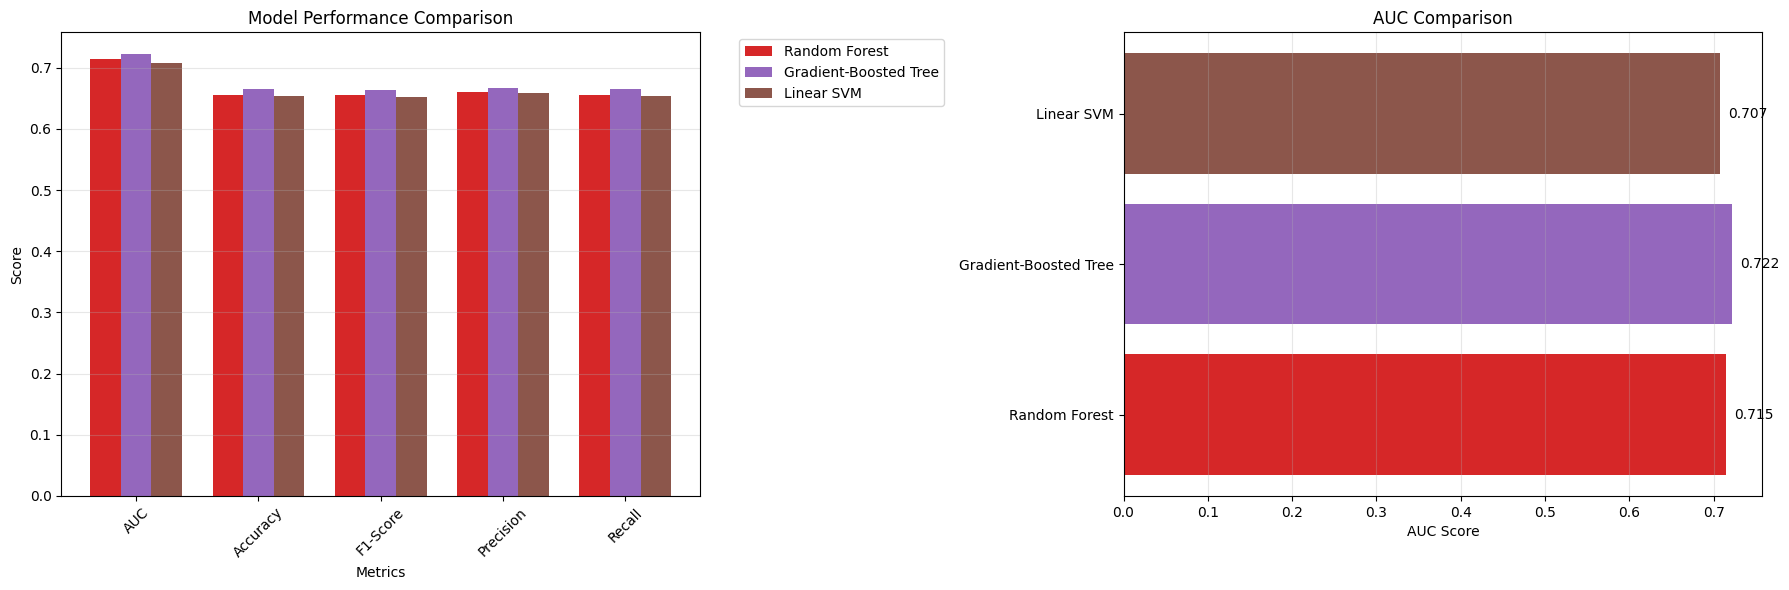

In [19]:
# Comparison of 3 algorithms implemented in this notebook (6CFU)
comparison_df = pd.DataFrame({
    'Model': [
        'Random Forest', 'Gradient-Boosted Tree', 'Linear SVM'
    ],
    'AUC': [
        rf_metrics['AUC'], gbt_metrics['AUC'], svm_metrics['AUC']
    ],
    'Accuracy': [
        rf_metrics['Accuracy'], gbt_metrics['Accuracy'], svm_metrics['Accuracy']
    ],
    'F1-Score': [
        rf_metrics['F1-Score'], gbt_metrics['F1-Score'], svm_metrics['F1-Score']
    ],
    'Precision': [
        rf_metrics['Precision'], gbt_metrics['Precision'], svm_metrics['Precision']
    ],
    'Recall': [
        rf_metrics['Recall'], gbt_metrics['Recall'], svm_metrics['Recall']
    ]
})

print(comparison_df.to_string(index=False))

# Find best performing model for each metric
print(f"\nBest AUC: {comparison_df.loc[comparison_df['AUC'].idxmax(), 'Model']} ({comparison_df['AUC'].max():.4f})")
print(f"Best Accuracy: {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"Best F1-Score: {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"Best Precision: {comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']} ({comparison_df['Precision'].max():.4f})")
print(f"Best Recall: {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Bar chart for all metrics
metrics_to_plot = ['AUC', 'Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#d62728', '#9467bd', '#8c564b']  # 3 colors for 3 models

for i, (model, color) in enumerate(zip(comparison_df['Model'], colors)):
    values = [comparison_df.loc[comparison_df['Model'] == model, metric].values[0] for metric in metrics_to_plot]
    axes[0].bar(x + i*width, values, width, label=model, color=color)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# 2. AUC comparison
models = comparison_df['Model']
aucs = comparison_df['AUC']
bars = axes[1].barh(models, aucs, color=colors)
axes[1].set_xlabel('AUC Score')
axes[1].set_title('AUC Comparison')
axes[1].grid(axis='x', alpha=0.3)
# Add value labels on bars
for bar, auc_val in zip(bars, aucs):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                  f'{auc_val:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### ROC Curves 

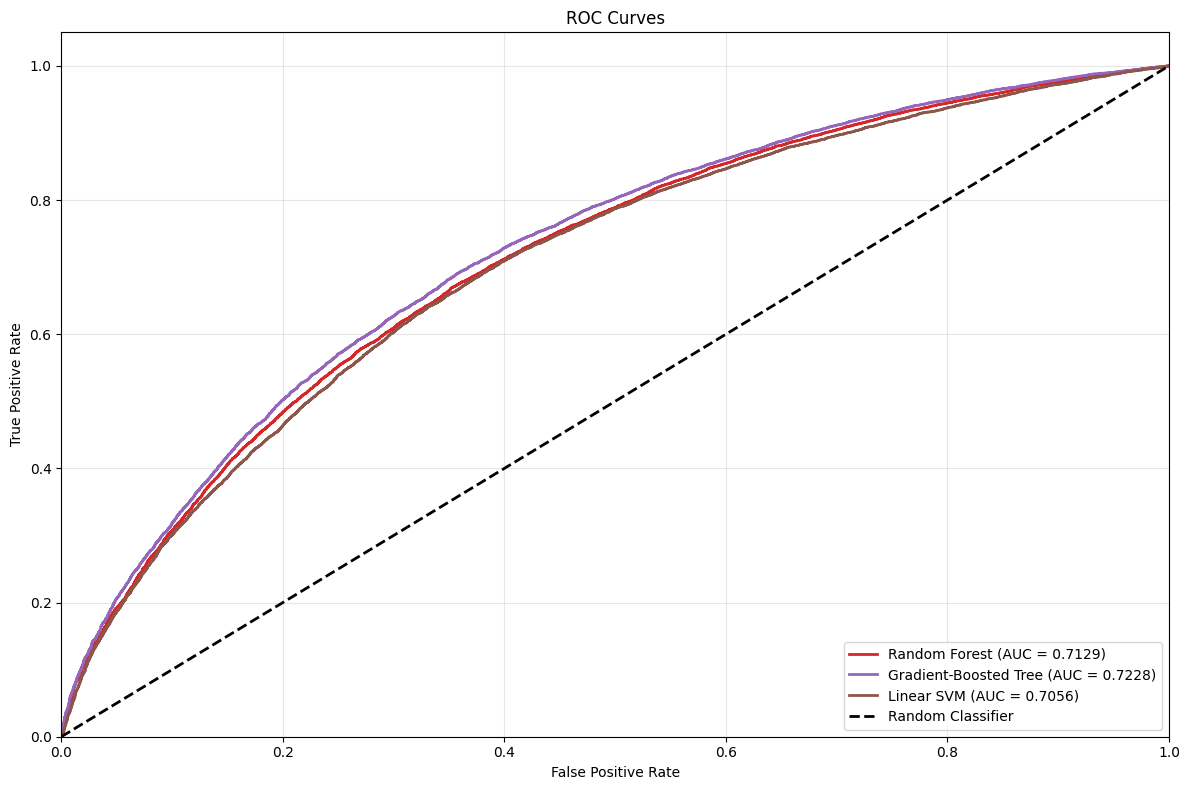

26/02/01 00:53:39 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apache.spark.storage.BlockManagerMasterE

In [ ]:
# Plot ROC curves for the 3 advanced classifiers
plt.figure(figsize=(12, 8))

# Models data for this notebook
models_data = [
    ('Random Forest', rf_predictions, '#d62728'),
    ('Gradient-Boosted Tree', gbt_predictions, '#9467bd'), 
    ('Linear SVM', svm_predictions, '#8c564b')
]

for model_name, predictions_list, color in models_data:
    # Combine all windows
    all_labels = []
    all_probs = []
    
    for pred_df in predictions_list:
        all_labels.extend(pred_df['label'].values)
        if 'probability' in pred_df.columns:
            # For models with probability output (RF, GBT)
            probs = [p[1] if len(p) > 1 else p[0] for p in pred_df['probability'].values]
        else:
            # For Linear SVM (no probability, use prediction/rawPrediction)
            # We'll use a simple approach for SVM ROC
            probs = pred_df.get('prediction', pred_df.get('rawPrediction', [0.5] * len(pred_df))).values
            if hasattr(probs[0], '__len__') and len(probs[0]) > 1:
                probs = [p[1] for p in probs]
        all_probs.extend(probs)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()